In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=19526 sha256=733e25971032b29adb6495719f02a5853bba3ed2a0a1aa1aae4c4d818e197a40
  Stored in directory: /tmp/pip-ephem-wheel-cache-k_5vyhc4/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr

#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine
import seaborn as sns
import fwiVis.fwiVis as fv

In [3]:
fire3 = fv.formatting_read_in("data/Quebec_v3_full_data_perimeters20241112.csv", start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True )

Skipping field prov_code: unsupported OGR type: 5
Skipping field prov_name_en: unsupported OGR type: 5


In [4]:
thresh = 1
thresh_relative = 0.05
def get_num_fires(df, thresh = thresh, var = "farea_diff_stand"):
    n = len(df[df[var] > thresh].fireID.unique())
    return(n)

def get_percent_fires_spread(df, thresh = thresh, var = "farea_diff_stand"):
    
    n = len(df.fireID.unique())
    n_thresh = len(df[df[var] > thresh].fireID.unique())
    if(n == 0):
        print(f"{n} fires on the landscape.")
        return(n)
    return(n_thresh/n)
    
num_fires = fire3.groupby("t").apply(get_num_fires).reset_index()
num_fires_rel_growth = fire3.groupby("t").apply(lambda x: get_num_fires(x, thresh = thresh_relative, var = "frac_change")).reset_index()
percent_fires = fire3.groupby("t").apply(get_percent_fires_spread).reset_index()
percent_fires.rename(columns={0 : "percent_fires"})
percent_fires.loc[:,"FWI_spread"] = ""
num_fires.rename(columns={0 : "num_fires"})
num_fires.loc[:,"FWI_spread"] = ""
num_fires_rel_growth.rename(columns={0 : "num_fires"})
num_fires_rel_growth.loc[:, "FWI_spread"] = ""

FWI_var = 'GEOS5_IMERGEARLY'#"GEOS-5.IMERGEARLY" GEOS_IMERGEARLY
#def get_fwi_spread_at_day(df, num_fires = num_fires, FWI_var = "GEOS-5.IMERGEARLY"):
df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in num_fires.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    num_fires.loc[num_fires.t == t, "FWI_spread"] =  str(tmp)

df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in percent_fires.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    percent_fires.loc[percent_fires.t == t, "FWI_spread"] =  str(tmp)


df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in num_fires_rel_growth.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    num_fires_rel_growth.loc[num_fires_rel_growth.t == t, "FWI_spread"] =  str(tmp)

/tmp/ipykernel_3383/1518717116.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_3383/1518717116.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_3383/1518717116.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pas

In [5]:
import ast

# Convert to a list of actual Python lists
converted_lists = [ast.literal_eval(x) for x in num_fires['FWI_spread']]
flattened_list = [item for sublist in converted_lists for item in sublist]


In [6]:
def condense_by_num_fires_spreading(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]

    df.loc[:, "max_fwi"] =  np.max(flattened_list)
    df.loc[:, "min_fwi"] = np.min(flattened_list)
    df.loc[:, "mean_fwi"] = np.mean(flattened_list)
    df.loc[:, "all_vals"] = str(flattened_list)
    df.loc[:, "75_percent"] = np.quantile(flattened_list, 0.75)
    df.loc[:, "25_percent"] = np.quantile(flattened_list, 0.25)
    df.loc[:, "975_percent"] = np.quantile(flattened_list, 0.975)
    df.loc[:, "025_percent"] = np.quantile(flattened_list, 0.025)
    
    

    return(df)
    
# def condense_by_num_fires_spreading(df):

#      #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
#     converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
#     flattened_list = [item for sublist in converted_lists for item in sublist]

#     df.loc[:, "max_fwi"] =  np.max(flattened_list)
#     df.loc[:, "min_fwi"] = np.min(flattened_list)
#     df.loc[:, "mean_fwi"] = np.mean(flattened_list)
#     df.loc[:, "all_vals"] = str(flattened_list)
#     df.loc[:, "75_percent"] = np.quantile(flattened_list, 0.75)
#     df.loc[:, "25_percent"] = np.quantile(flattened_list, 0.25)
#     df.loc[:, "975_percent"] = np.quantile(flattened_list, 0.975)
#     df.loc[:, "025_percent"] = np.quantile(flattened_list, 0.025)
    
    

#     return(df)

def num_fires_spreading_FWI_vals(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]

    return(flattened_list)

def num_fires_spreading_long_df(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]
    new_df = pd.DataFrame({"FWI_spread": flattened_list, 
                            })
    new_df.loc[:, "num_fires"] = df[0]

    return(new_df)
    

    
        
num_test = num_fires.copy()

num_test = num_test.groupby(0).apply(condense_by_num_fires_spreading)

num_test = num_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
num_test = num_test.rename(columns = {0: "num_fires"})
vals = num_fires.groupby(0).t.count()
num_test["day_count"] = ""
#num_test["day_count"] = num_test["day_count"].map(vals)
num_test["day_count"] = vals.values


percent_test = percent_fires.copy()
percent_test = percent_test.groupby(0).apply(condense_by_num_fires_spreading)

percent_test = percent_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
percent_test = percent_test.rename(columns = {0: "percent_fires"})
vals = percent_fires.groupby(0).t.count()
percent_test["day_count"] = ""
percent_test["day_count"] = vals.values

percent_test_sm = percent_fires.copy()
percent_test_sm[0] = percent_test_sm[0].round(1)
percent_test_sm = percent_test_sm.groupby(0).apply(condense_by_num_fires_spreading).reset_index(drop = True)
percent_fires_rn = percent_fires.copy()
percent_fires_rn[0] = percent_fires_rn[0].round(1)
vals = percent_fires_rn.groupby(0).t.count()


percent_test_sm = percent_test_sm[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
percent_test_sm = percent_test_sm.rename(columns = {0: "percent_fires"})
percent_test_sm["day_count"] = ""
#percent_test_sm["day_count"] = percent_test_sm["day_count"].map(vals)
percent_test_sm["day_count"] = vals.values

#num_test_raw = num_test.groupby("num_fires").apply(condense_by_num_fires_spreading)

# num_test_raw = num_fires.copy()

# num_test_raw = num_test_raw.groupby(0).apply(num_fires_spreading_long_df).reset_index()


num_fires_rel_growth_test  = num_fires_rel_growth.copy()
num_fires_rel_growth_test = num_fires_rel_growth_test.groupby(0).apply(condense_by_num_fires_spreading)
num_fires_rel_growth_test = num_fires_rel_growth_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
num_fires_rel_growth_test = num_fires_rel_growth_test.rename(columns = {0: "num_fires"})
vals = num_fires_rel_growth.groupby(0).t.count()
num_fires_rel_growth_test["day_count"] = ""
num_fires_rel_growth_test["day_count"] = vals.values

/tmp/ipykernel_3383/1274947822.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_3383/1274947822.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_3383/1274947822.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pas

In [7]:
import matplotlib.cm as cm

import matplotlib.colors as mc
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import colorsys

# Retrieve the original colormap
original_cmap = plt.get_cmap('spring_r')

def create_darker_colormap(base_cmap_name, darkness_factor):
    """
    Create a darker version of a given colormap.
    
    Parameters:
    - base_cmap_name: str, the name of the base colormap.
    - darkness_factor: float, a factor between 0 and 1 to darken the colormap.
                       1 means no change, 0 means completely dark.
    
    Returns:
    - LinearSegmentedColormap: a new colormap that is a darker version of the base colormap.
    """
    # Retrieve the original colormap
    base_cmap = plt.get_cmap(base_cmap_name)
    
    # Create a list of colors from the colormap and darken them
    colors = base_cmap(np.linspace(0, 1, 256))
    colors[:, :3] *= darkness_factor
    colors = np.clip(colors, 0, 1)  # Ensure values are within [0, 1]
    
    # Create the new colormap
    return LinearSegmentedColormap.from_list(f"{base_cmap_name}_darker", colors)

def darken_color(color, scale):
    """Darkens a color by scaling its lightness in HLS space.

    Args:
        color: An RGB tuple, hex code, or color name.
        scale: A value between 0 and 1 to scale the lightness (0 is black, 1 is no change).

    Returns:
        A darkened color in RGB tuple format.
    """
    
    rgb = mc.to_rgb(color)
    hls = colorsys.rgb_to_hls(*rgb)
    new_lightness = hls[1] * scale
    new_rgb = colorsys.hls_to_rgb(hls[0], new_lightness, hls[2])
    return new_rgb
    

# Define the darkness factor (between 0 and 1)
darkness_factor = 0.85

# Create a custom colormap with the specified darkness factor
darker_cmap = create_darker_colormap('spring_r', darkness_factor)

# data = {
#     'category': ['A', 'B', 'C', 'D', 'E'] * 10,
#     'count': np.random.randint(1, 6, 50),
#     'quality': np.random.uniform(0, 1, 50)
# }
# df = pd.DataFrame(data)

# df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# # Correct aggregation: take the first count for each category (since they're repeated)
# df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()

# # Create the plot
# fig, ax = plt.subplots(figsize=(12, 8))

# # Calculate point size to make them touch
# max_count = df_agg['day_count'].max()
# point_size = (1 / max_count) * ax.get_window_extent().height
# #val_range = np.arange(df[f'days_since_{tmin}'].max() + 1)

# cmap = cm.viridis
# norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())


# # Create a ScalarMappable
# scalar_map = cm.ScalarMappable(cmap=cmap)
# scalar_map.set_array([])

# # Map values to RGBA colors
# #rgba_colors = scalar_map.to_rgba(val_range / (df[f'days_since_{tmin}'].max() + 1))

# for i, row in df_agg.iterrows():
#     category = row['num_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
#     #qualities[:]  = [x /  (df[f'days_since_{tmin}'].max() + 1) for x in qualities]
#     print(qualities)
#     x = [i] * count
#     y = np.arange(count) + 1
    
#     #scatter = ax.scatter(x, y, c=qualities, cmap='viridis', s=point_size*7, edgecolor='none')
#     #scatter = ax.scatter(x, y, c=scalar_map.to_rgba(qualities), s=point_size*7, edgecolor='none')
#     scatter = ax.scatter(x, y, c = qualities, cmap=darker_cmap, norm = norm,  s=point_size*7, edgecolor='none')

# # Customize the plot
# ax.set_xticks(range(len(df_agg)))
# ax.set_xticklabels(df_agg['num_fires'])
# ax.set_ylabel('Count')
# #ax.set_title('Bar Graph-Style Plot with Aligned, Touching Colored Points')

# # Set y-axis limits and ticks
# #ax.set_ylim(-0.5, max_count - 0.5)
# #ax.set_yticks(range(0, max_count + 1))

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# # Add a colorbar
# cbar = plt.colorbar(scatter)
# cbar.set_label('Number of Days since 5/31')

# # #plt.tight_layout()
# plt.show()

In [8]:
## Merge both df's together to get the dates tied to a specific # of fires and vice versa
num_fires = num_fires.rename(columns = {0: "num_fires"})
percent_fires = percent_fires.rename(columns = {0: "percent_fires"})

#percent_test = percent_test.reset_index()
#percent_test = percent_test.rename(columns = {0: "num_fires"})


num_merge = num_test.reset_index(drop = True).merge(num_fires.reset_index(drop = True), on = "num_fires" )
percent_merge = percent_test.reset_index(drop = True).merge(percent_fires.reset_index(drop = True), on = "percent_fires")


counts = num_merge.day_count
categories = num_merge.num_fires

pcounts = percent_merge.day_count
pcategories = percent_merge.percent_fires

tmin = num_merge.t.astype("datetime64[ns]").min()
num_merge[f"days_since"] = num_merge.t.astype("datetime64[ns]") - tmin
percent_merge[f"days_since"] = percent_merge.t.astype("datetime64[ns]") - tmin

num_merge[f"days_since_{tmin}"] = num_merge[f"days_since"].dt.days
percent_merge[f"days_since_{tmin}"] = percent_merge[f"days_since"].dt.days

qualities = num_merge[f"days_since_{tmin}"].astype("int")#num_merge.t.astype("datetime64[ns]").dt.hours()
pqualities = percent_merge[f"days_since_{tmin}"].astype("int")


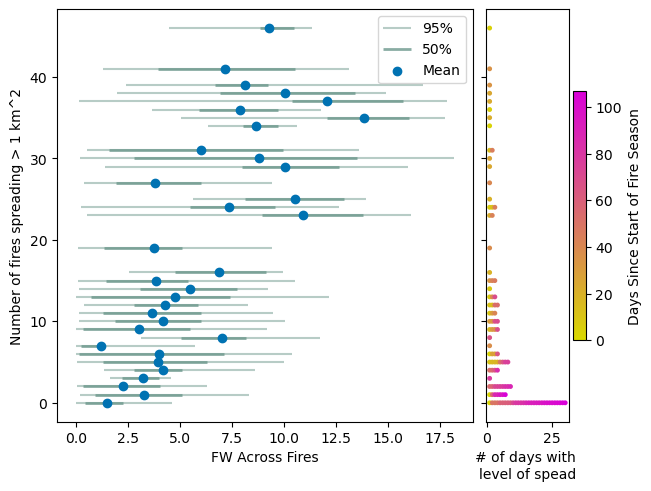

In [9]:
## combining both plots


df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(1, 2, gridspec_kw={ 'width_ratios': [10,2]},sharey=True, constrained_layout=True) # 

# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)
ax.hlines(y = num_test.num_fires, xmin =num_test['025_percent'], xmax = num_test['975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.hlines(y = num_test.num_fires, xmin =num_test['25_percent'], xmax = num_test['75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(y = num_test.num_fires, x = num_test.mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()




# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FW Across Fires")
ax.set_ylabel(f"Number of fires spreading > {thresh} km^2")

#### Dot plot
# ax2.barh(num_test.num_fires, num_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height
# for i, row in df_agg.iterrows():
#     category = row['num_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for category, group in df.groupby('num_fires'):
    count = group['day_count'].iloc[0]
    qualities = group[f'days_since_{tmin}'].tolist()
    y_value = category #group['num_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x = np.arange(count) + 1
    y = [y_value] * count
    
    ax2.scatter(x, y, c=qualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
# categories = df['num_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['num_fires'])
ax2.set_xlabel("# of days with \nlevel of spead")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
cbar = fig.colorbar(sm, ax = ax2, orientation='vertical', label = f"Days Since Start of Fire Season")
plt.savefig(f"some_figs/fires_spread_fwi_distribution/cbar_with_dots_number_fires_spread_{thresh}.png")

plt.show()

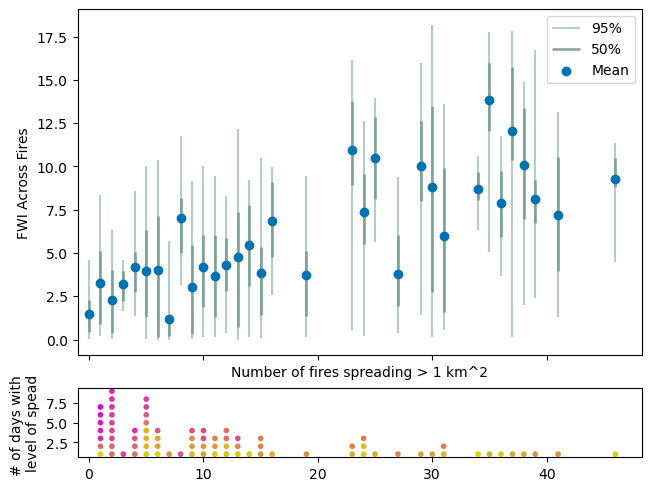

In [10]:
### Try without zeros

## combining both plots


df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(2, 1, gridspec_kw={ 'height_ratios': [10,2]},sharex=True, constrained_layout=True) # 

# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)
ax.vlines(x = num_test.num_fires, ymin =num_test['025_percent'], ymax = num_test['975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.vlines(x = num_test.num_fires, ymin =num_test['25_percent'], ymax = num_test['75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(x = num_test.num_fires, y = num_test.mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()




# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_ylabel("FWI Across Fires")
ax.set_xlabel(f"Number of fires spreading > {thresh} km^2")

#### Dot plot
# ax2.barh(num_test.num_fires, num_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height * 9
# for i, row in df_agg.iterrows():
#     category = row['num_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for category, group in df[df.num_fires > 0].groupby('num_fires'):
    count = group['day_count'].iloc[0]
    qualities = group[f'days_since_{tmin}'].tolist()
    y_value = category #group['num_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x = np.arange(count) + 1
    y = [y_value] * count
    
    ax2.scatter(y, x, c=qualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
    ax2.set_xlim(xmin = -1)
# categories = df['num_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['num_fires'])
ax2.set_ylabel("# of days with \nlevel of spead")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
#cbar = fig.colorbar(sm, ax = ax2, label = f"Days Since Start of Fire Season") #  orientation='horizontal'
plt.savefig(f"some_figs/fires_spread_fwi_distribution/reverse_axis_no_zeros_cbar_with_dots_number_fires_spread_{thresh}.png")

plt.show()

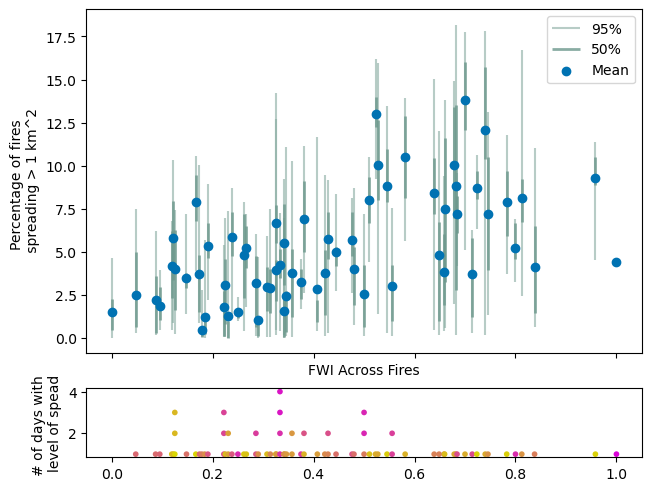

In [11]:

df = percent_merge[['percent_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('percent_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(2, 1, gridspec_kw={ 'height_ratios': [10,2]},sharex=True, constrained_layout=True) # 

# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)
ax.vlines(x = percent_test.percent_fires, ymin =percent_test['025_percent'], ymax = percent_test['975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.vlines(x = percent_test.percent_fires, ymin =percent_test['25_percent'], ymax = percent_test['75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(x = percent_test.percent_fires, y = percent_test.mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()




# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FWI Across Fires")
ax.set_ylabel(f"Percentage of fires \n spreading > {thresh} km^2")

#### Dot plot
# ax2.barh(percent_test.percent_fires, percent_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height * 9
# for i, row in df_agg.iterrows():
#     category = row['percent_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for pcategory, group in df[df.percent_fires > 0].groupby('percent_fires'):
    pcount = group['day_count'].iloc[0]
    #print("pecount", pcount)
    pqualities = group[f'days_since_{tmin}'].tolist()
    #print("pqualities", pqualities)
    
    y_value = pcategory #group['percent_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print("pcategory", pcategory)
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x =  np.arange(pcount) + 1
    y = [y_value] * pcount
    # print("x", x)
    # print("y", y)
    
    ax2.scatter(y, x, c=pqualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
    #ax2.set_xlim(xmin = 0, xmax = df[df.percent_fires > 0].day_count.max() + 1)
# categories = df['percent_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['percent_fires'])
ax2.set_ylabel("# of days with \nlevel of spead")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
#cbar = fig.colorbar(sm, ax = ax2, orientation='vertical', label = f"Days Since Start of Fire Season")
plt.savefig(f"some_figs/fires_spread_fwi_distribution/percent_no_zeros_cbar_with_dots_number_fires_spread_{thresh}.png")

plt.show()